# Istanbul Emergency Logistics Hub Optimization

This project finds a possible location for one emergency logistics hub in Istanbul.

The hub should be close to important health facilities. Facilities in districts with higher earthquake risk get higher weights.

In this version, the code is divided into small blocks. I use common data science libraries instead of writing very complex optimization code manually.

## 1. Libraries

Main libraries:

- `pandas`: reading and cleaning tables
- `numpy`: numerical calculations
- `matplotlib`: plots
- `scipy.optimize`: optimization methods
- `sklearn.preprocessing`: scaling risk scores
- `ipywidgets`: slider for `n`

In [1]:
from pathlib import Path
import urllib.request
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import folium

plt.style.use('seaborn-v0_8-whitegrid')

data_dir = Path('data')
out_dir = Path('outputs')
data_dir.mkdir(exist_ok=True)
out_dir.mkdir(exist_ok=True)

## 2. Data Links

Health facilities dataset page:  
https://data.ibb.gov.tr/dataset/istanbul-saglik-kurum-ve-kuruluslari-verisi

Health facilities direct file:  
https://data.ibb.gov.tr/dataset/bd3b9489-c7d5-4ff3-897c-8667f57c70bb/resource/f2154883-68e3-41dc-b2be-a6c2eb721c9e/download/saglik-tesisleri.xlsx

Earthquake scenario dataset page:  
https://data.ibb.gov.tr/dataset/deprem-senaryosu-analiz-sonuclari

Earthquake scenario direct file:  
https://data.ibb.gov.tr/dataset/c13514d9-86b1-4b83-a9b9-1a15cb5f254c/resource/9c3ac492-de4b-4245-b418-7ad3df67a193/download/deprem-senaryosu-analiz-sonuclar.csv

In [2]:
health_url = 'https://data.ibb.gov.tr/dataset/bd3b9489-c7d5-4ff3-897c-8667f57c70bb/resource/f2154883-68e3-41dc-b2be-a6c2eb721c9e/download/saglik-tesisleri.xlsx'
earthquake_url = 'https://data.ibb.gov.tr/dataset/c13514d9-86b1-4b83-a9b9-1a15cb5f254c/resource/9c3ac492-de4b-4245-b418-7ad3df67a193/download/deprem-senaryosu-analiz-sonuclar.csv'

health_file = data_dir / 'saglik-tesisleri.xlsx'
earthquake_file = data_dir / 'deprem-senaryosu-analiz-sonuclari.csv'

if not health_file.exists():
    urllib.request.urlretrieve(health_url, health_file)

if not earthquake_file.exists():
    urllib.request.urlretrieve(earthquake_url, earthquake_file)

print('Files are ready.')

Files are ready.


## 3. Read Data

In [3]:
health = pd.read_excel(health_file)
earthquake = pd.read_csv(earthquake_file, sep=';', encoding='cp1254')

In [4]:
health.columns = ['name', 'main_category', 'sub_category', 'district', 'neighborhood', 'address', 'lat', 'lon']

earthquake.columns = [
    'district', 'neighborhood', 'uavt', 'very_heavy_damage', 'heavy_damage',
    'medium_damage', 'light_damage', 'deaths', 'severe_injuries',
    'hospital_treatment', 'light_injuries', 'gas_pipe_damage',
    'water_pipe_damage', 'wastewater_damage', 'temporary_shelter'
]

health['district'] = health['district'].replace({'EY?PSULTAN': 'EY?P'})

In [5]:
print('Health rows:', len(health))
print('Earthquake rows:', len(earthquake))
print('Health districts:', health['district'].nunique())
print('Earthquake districts:', earthquake['district'].nunique())

health.head()

Health rows: 20469
Earthquake rows: 959
Health districts: 39
Earthquake districts: 39


,name,main_category,sub_category,district,neighborhood,address,lat,lon
0,Ada Medikal Diğer Tıbbi Malz Satışı,Sağlık,Medikal,BEYKOZ,YALIKÖY,Çayır Cad. No:25 F YALIKÖY/BEYKOZ,41.139505,29.086857
1,Uzman Dental Ağız ve Diş Sağlığı Polikliniği,Sağlık,Özel Ağız ve Diş Sağlığı Merkezleri,BAĞCILAR,YAVUZ SELİM,Birlik Cad. No:15 YAVUZ SELİM/BAĞCILAR,41.035575,28.853850
2,Özel Moda Polikliniği,Sağlık,Poliklinik Özel,KADIKÖY,CAFERAĞA,Mühürdar Karakolu Sk. No:1 -3A CAFERAĞA/KADIKÖY,40.984577,29.024374
3,Op. Dr. Ayça Çarak,Sağlık,Doktor/Muayenehane,ŞİŞLİ,TEŞVİKİYE,Şakayık Sk. No:4 TEŞVİKİYE/ŞİŞLİ,41.049313,28.996088
4,Özeller Saat Optik,Sağlık,Gözlükçü/Optik,ESENYURT,SULTANİYE,Doğan Araslı Bulvarı No:168 SULTANİYE/ESENYURT,41.034132,28.680531


In [6]:
earthquake.head()

,district,neighborhood,uavt,very_heavy_damage,heavy_damage,medium_damage,light_damage,deaths,severe_injuries,hospital_treatment,light_injuries,gas_pipe_damage,water_pipe_damage,wastewater_damage,temporary_shelter
0,ADALAR,BURGAZADA,40139,54,99,256,241,8,6,24,42,0,0,1,398
1,ADALAR,HEYBELİADA,40142,101,175,423,393,25,21,66,113,1,1,2,763
2,ADALAR,KINALIADA,40143,53,97,287,302,5,3,15,27,0,1,1,420
3,ADALAR,MADEN,40140,104,192,483,484,22,18,64,113,1,1,2,847
4,ADALAR,NİZAM,40141,101,180,445,422,16,13,48,83,1,2,2,687


## 4. EDA: Health Facility Categories

The health dataset is large, but not every row is useful for our emergency hub model. For example, there are many pharmacies, dentists, opticians, and medical stores.

First I look at the most common categories.

In [7]:
category_counts = health['sub_category'].value_counts()
category_counts.head(20)

sub_category
Eczane                                     5806
Sağlık Diğer                               2460
Gözlükçü/Optik                             1672
Diş Hekimi                                 1649
Doktor/Muayenehane                         1543
Özel Ağız ve Diş Sağlığı Merkezleri        1317
Medikal                                    1208
Aile Sağlığı Merkezi                       1057
Veteriner                                   791
Psikologlar                                 556
Ecza Deposu                                 298
Özel Hastane                                269
İşitme Cihazı Satış ve Uygulama Merkezi     245
Tıp Merkezi Özel                            162
Diyetisyen                                  155
Laboratuvar Özel                            135
Sağlık Kabini Özel                           89
Yaşlı Bakım Evi/Huzurevi                     85
Psikoteknik Değerlendirme Merkezi            83
Devlet Hastanesi                             81
Name: count, dtype: int64

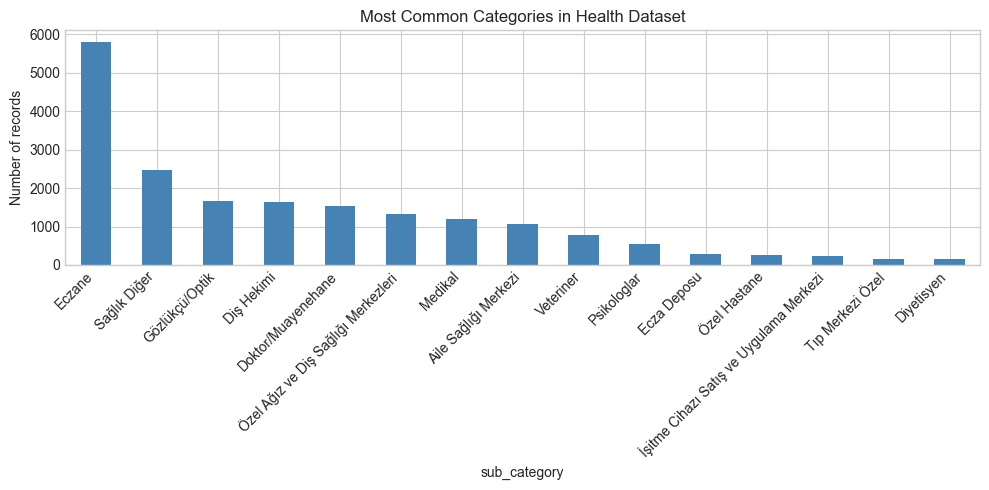

In [8]:
plt.figure(figsize=(10, 5))
category_counts.head(15).plot(kind='bar', color='steelblue')
plt.title('Most Common Categories in Health Dataset')
plt.ylabel('Number of records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(out_dir / 'eda_health_categories.png', dpi=150)
plt.show()

## 5. Which Categories Should Be Used?

For this project, the hub is for emergency logistics after an earthquake. So I do not use every health-related place.

I remove categories like:

- pharmacies
- dentists
- opticians
- medical stores
- veterinarians

I keep categories that are more related to emergency treatment and healthcare response.

In [9]:
category_pattern = 'Hastane|Poliklinik|Diyaliz|Fizik|Aile|Acil|Verem|Kan'

selected_health = health[
    health['sub_category'].str.contains(category_pattern, case=False, na=False)
].copy()

print('All health records:', len(health))
print('Selected records:', len(selected_health))
print('Removed records:', len(health) - len(selected_health))
print('Selected districts:', selected_health['district'].nunique())

selected_health['sub_category'].value_counts()

All health records: 20469
Selected records: 1881
Removed records: 18588
Selected districts: 39


sub_category
Aile Sağlığı Merkezi                           1057
Özel Hastane                                    269
Devlet Hastanesi                                 81
Poliklinik Özel                                  74
Şehir Hastanesi                                  66
Eğitim Araştırma Hastanesi                       56
Rehabilitasyon ve Aile Danışma Merkezi           55
Üniversite Hastanesi                             45
Diyaliz Merkezi Özel                             40
Fizik Tedavi ve Rehabilitasyon Merkezi Özel      28
Verem Savaş Dispanseri                           27
Kızılay/Kan Merkezi                              22
Semt Poliklinikleri                              22
Acil Yardım İstasyonu                            19
Kadın Doğum ve Çocuk Hastanesi                   11
Diyaliz Merkezi                                   6
Fizik Tedavi ve Rehabilitasyon Merkezi            3
Name: count, dtype: int64

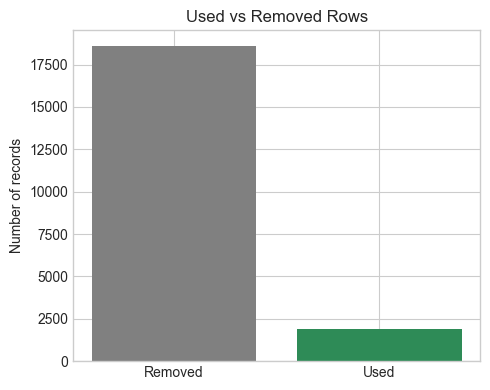

In [10]:
plt.figure(figsize=(5, 4))
plt.bar(['Removed', 'Used'], [len(health) - len(selected_health), len(selected_health)], color=['gray', 'seagreen'])
plt.title('Used vs Removed Rows')
plt.ylabel('Number of records')
plt.tight_layout()
plt.savefig(out_dir / 'eda_used_removed.png', dpi=150)
plt.show()

## 6. Earthquake Risk Score

The earthquake dataset is at neighborhood level. I group it by district and calculate a risk score.

This is the score used in this project, not an official risk score.

In [11]:
risk = earthquake.groupby('district', as_index=False).sum(numeric_only=True)

risk['casualty_part'] = risk['deaths'] + risk['severe_injuries'] + risk['hospital_treatment']
risk['damage_part'] = 2 * risk['very_heavy_damage'] + risk['heavy_damage'] + 0.5 * risk['medium_damage']
risk['shelter_part'] = risk['temporary_shelter']

risk['risk_score'] = 3 * risk['casualty_part'] + 1 * risk['damage_part'] + 0.02 * risk['shelter_part']

In [12]:
scaler = MinMaxScaler(feature_range=(0.5, 2.0))
risk['risk_weight'] = scaler.fit_transform(risk[['risk_score']])

risk.sort_values('risk_score', ascending=False).head(10)

,district,uavt,very_heavy_damage,heavy_damage,medium_damage,light_damage,deaths,severe_injuries,hospital_treatment,light_injuries,gas_pipe_damage,water_pipe_damage,wastewater_damage,temporary_shelter,casualty_part,damage_part,shelter_part,risk_score,risk_weight
17,FATİH,3474985,2083,3496,9949,15758,1484,985,3897,6767,11,18,43,46784,6366,12636.5,46784,32670.18,2.000000
23,KÜÇÜKÇEKMECE,852510,1240,2616,8978,13799,1515,925,4079,7413,21,25,63,72774,6519,9585.0,72774,30597.48,1.903192
4,BAHÇELİEVLER,442002,796,1490,5668,9686,1633,879,4261,7599,17,21,52,61199,6773,5916.0,61199,27458.98,1.756605
7,BAĞCILAR,883641,796,1825,8001,15397,1179,652,3148,5869,16,20,52,59513,4979,7417.5,59513,23544.76,1.573786
15,ESENYURT,4991823,563,1768,7911,14672,1003,543,2789,5441,24,28,63,67410,4335,6849.5,67410,21202.70,1.464398
5,BAKIRKÖY,602925,782,1306,3394,3939,1046,581,2701,4610,15,17,48,28910,4328,4567.0,28910,18129.20,1.320846
32,ZEYTİNBURNU,530881,510,1025,3799,6335,668,374,1767,3206,8,11,30,31030,2809,3944.5,31030,12992.10,1.080912
19,GÜNGÖREN,445511,342,611,2407,4597,754,415,1965,3496,7,9,24,27478,3134,2498.5,27478,12450.06,1.055595
14,ESENLER,645560,391,813,3739,8302,638,352,1687,3133,6,7,20,29747,2677,3464.5,29747,12090.44,1.038799
6,BAYRAMPAŞA,442288,614,1182,4059,7415,520,340,1394,2529,5,8,19,23064,2254,4439.5,23064,11662.78,1.018824


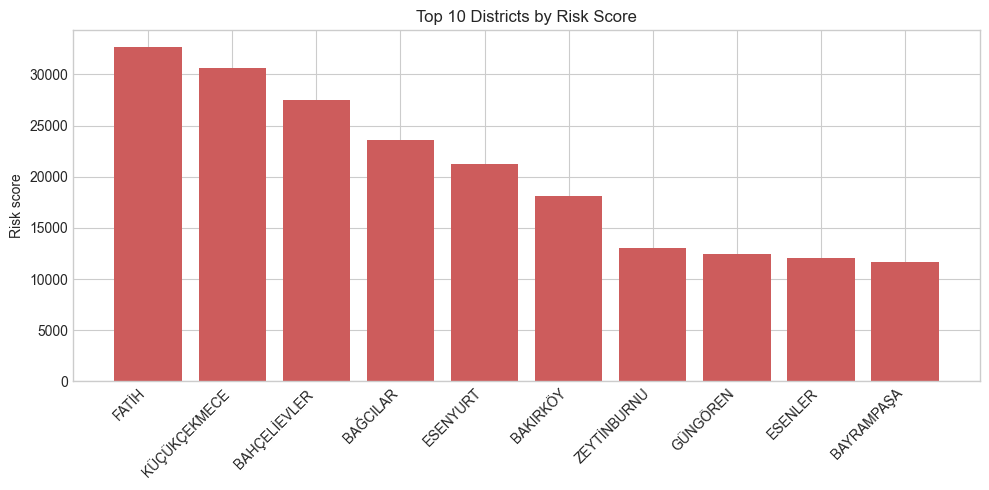

In [13]:
top_risk = risk.sort_values('risk_score', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_risk['district'], top_risk['risk_score'], color='indianred')
plt.title('Top 10 Districts by Risk Score')
plt.ylabel('Risk score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(out_dir / 'top_district_risk.png', dpi=150)
plt.show()

## 7. Merge Facility Data with Risk Data

Now I combine selected health facilities with district risk weights.

Hospitals get a higher priority because they are more important in emergency response.

In [14]:
def priority(category):
    if 'Hastane' in category or 'Hastanesi' in category:
        return 1.5
    if 'Acil' in category:
        return 1.4
    if 'Poliklinik' in category:
        return 1.2
    if 'Diyaliz' in category:
        return 1.1
    return 1.0

In [15]:
model_data = selected_health.merge(
    risk[['district', 'risk_score', 'risk_weight']],
    on='district',
    how='inner'
)

model_data['facility_priority'] = model_data['sub_category'].apply(priority)
model_data['weight'] = model_data['risk_weight'] * model_data['facility_priority']

model_data = model_data.sort_values('weight', ascending=False).reset_index(drop=True)

print('Rows used in model:', len(model_data))
model_data[['name', 'district', 'sub_category', 'lat', 'lon', 'weight']].head(10)

Rows used in model: 1845


,name,district,sub_category,lat,lon,weight
0,istanbul Şehir,FATİH,Şehir Hastanesi,41.002572,28.962583,3.0
1,Özel Balat Hastanesi,FATİH,Özel Hastane,41.038443,28.945532,3.0
2,İstanbul Üniversitesi İstanbul Tıp Fakültesi H...,FATİH,Üniversite Hastanesi,41.017140,28.934254,3.0
3,İstanbul Tıp Fakültesi Kemik İliği Bankası,FATİH,Üniversite Hastanesi,41.016411,28.932300,3.0
4,İstanbul Üniversitesi İstanbul Tıp Fakültesi H...,FATİH,Üniversite Hastanesi,41.017268,28.934390,3.0
5,İstanbul Bezmialem Vakıf Üniversitesi Sağlık U...,FATİH,Üniversite Hastanesi,41.018952,28.935714,3.0
6,Bezmiâlem Vakıf Üniversitesi Tıp Fakültesi Has...,FATİH,Üniversite Hastanesi,41.019151,28.936162,3.0
7,T.C. İstanbul Üniversitesi İstanbul Tıp Fakült...,FATİH,Üniversite Hastanesi,41.013821,28.962391,3.0
8,Çapa Hastahanesi Kadın Doğum Merkezi,FATİH,Kadın Doğum ve Çocuk Hastanesi,41.016656,28.934296,3.0
9,Cerrahpaşa Tıp Fakültesi Kadın Doğum,FATİH,Kadın Doğum ve Çocuk Hastanesi,41.004554,28.941336,3.0


## 8. Haversine Distance

Haversine distance is better than Euclidean distance for latitude and longitude coordinates.

In [16]:
R = 6371  # Earth radius in km

def haversine_distance(hub_lat, hub_lon, facility_lats, facility_lons):
    hub_lat = np.radians(hub_lat)
    hub_lon = np.radians(hub_lon)
    facility_lats = np.radians(facility_lats)
    facility_lons = np.radians(facility_lons)

    lat_diff = facility_lats - hub_lat
    lon_diff = facility_lons - hub_lon

    a = np.sin(lat_diff / 2) ** 2 + np.cos(hub_lat) * np.cos(facility_lats) * np.sin(lon_diff / 2) ** 2
    distance = 2 * R * np.arcsin(np.sqrt(a))
    return distance

## 9. Objective Function

The cost is weighted total distance.

I also use a small epsilon value. This is useful because the Weber objective is not differentiable when the hub is exactly on a facility coordinate. If Newton's method is used, this point can create numerical problems.

In [17]:
epsilon = 0.01

facility_lats = model_data['lat'].values
facility_lons = model_data['lon'].values
facility_weights = model_data['weight'].values

lat_min = model_data['lat'].min() - 0.02
lat_max = model_data['lat'].max() + 0.02
lon_min = model_data['lon'].min() - 0.02
lon_max = model_data['lon'].max() + 0.02

bounds = [(lat_min, lat_max), (lon_min, lon_max)]

In [18]:
def objective(point):
    hub_lat = point[0]
    hub_lon = point[1]

    distances = haversine_distance(hub_lat, hub_lon, facility_lats, facility_lons)
    smooth_distances = np.sqrt(distances ** 2 + epsilon ** 2)

    cost = np.sum(facility_weights * smooth_distances)
    return cost

In [19]:
start_lat = np.average(facility_lats, weights=facility_weights)
start_lon = np.average(facility_lons, weights=facility_weights)
start_point = [start_lat, start_lon]

print('Start point:', start_point)
print('Start cost:', objective(start_point))

Start point: [np.float64(41.014897868855186), np.float64(28.92918530277893)]
Start cost: 28250.09921250334


## 10. Optimization

I use SciPy optimization methods. This keeps the code shorter and easier to read.

I compare three methods:

- L-BFGS-B
- Powell
- Nelder-Mead

In [20]:
methods = ['L-BFGS-B', 'Powell', 'Nelder-Mead']
results = []

for method in methods:
    t0 = time.perf_counter()

    if method == 'Nelder-Mead':
        result = minimize(objective, start_point, method=method, options={'maxiter': 300})
    else:
        result = minimize(objective, start_point, method=method, bounds=bounds, options={'maxiter': 300})

    elapsed = time.perf_counter() - t0

    results.append({
        'method': method,
        'cost': result.fun,
        'hub_lat': result.x[0],
        'hub_lon': result.x[1],
        'iterations': result.nit,
        'time_seconds': elapsed
    })

results_df = pd.DataFrame(results).sort_values('cost')
results_df.to_csv(out_dir / 'optimization_results.csv', index=False)
results_df

,method,cost,hub_lat,hub_lon,iterations,time_seconds
0,L-BFGS-B,28198.538704,41.020036,28.923625,6,0.024112
2,Nelder-Mead,28198.538764,41.020041,28.923614,38,0.018660
1,Powell,28198.540732,41.020023,28.923561,2,0.023299


In [21]:
best = results_df.iloc[0]

hub_lat = best['hub_lat']
hub_lon = best['hub_lon']

print('Best method:', best['method'])
print('Hub latitude:', round(hub_lat, 6))
print('Hub longitude:', round(hub_lon, 6))
print('Cost:', round(best['cost'], 2))

Best method: L-BFGS-B
Hub latitude: 41.020036
Hub longitude: 28.923625
Cost: 28198.54


## 11. Method Comparison Plot

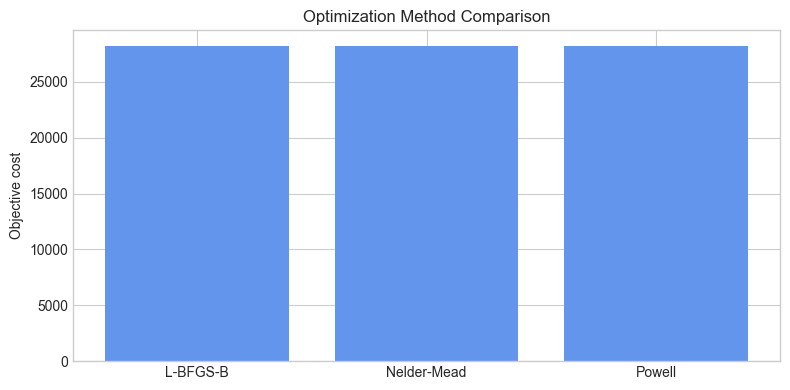

In [22]:
plt.figure(figsize=(8, 4))
plt.bar(results_df['method'], results_df['cost'], color='cornflowerblue')
plt.title('Optimization Method Comparison')
plt.ylabel('Objective cost')
plt.tight_layout()
plt.savefig(out_dir / 'method_comparison.png', dpi=150)
plt.show()

## 12. Hub Location Map

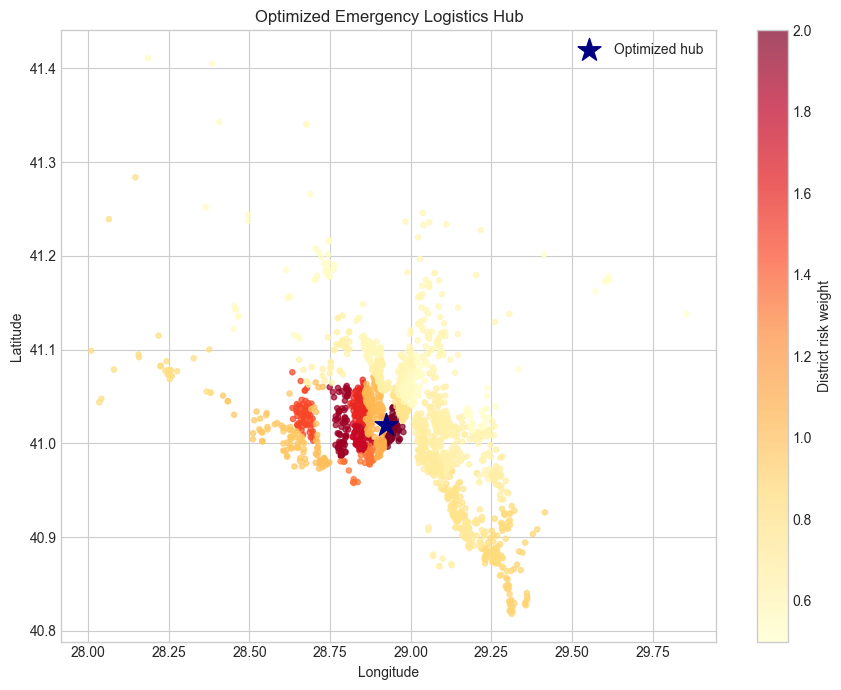

In [23]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    model_data['lon'], model_data['lat'],
    c=model_data['risk_weight'], cmap='YlOrRd', s=14, alpha=0.7
)
plt.scatter(hub_lon, hub_lat, marker='*', s=300, color='navy', label='Optimized hub')
plt.colorbar(scatter, label='District risk weight')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Optimized Emergency Logistics Hub')
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / 'optimized_hub_map.png', dpi=150)
plt.show()

## 13. Real Istanbul Map

The scatter plot is useful, but it does not show the real city map. So I also create an interactive OpenStreetMap map with `folium`.

To keep the map fast, I show the top 500 weighted facilities and the optimized hub point.

In [24]:
istanbul_map = folium.Map(location=[hub_lat, hub_lon], zoom_start=10, tiles='OpenStreetMap')

map_data = model_data.head(500)

for row in map_data.itertuples():
    if row.risk_weight > 1.5:
        color = 'red'
    elif row.risk_weight > 1.0:
        color = 'orange'
    else:
        color = 'green'

    popup_text = row.district + ' - ' + row.sub_category

    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=popup_text
    ).add_to(istanbul_map)

folium.Marker(
    location=[hub_lat, hub_lon],
    tooltip='Optimized hub',
    popup='Optimized emergency logistics hub',
    icon=folium.Icon(color='blue', icon='star')
).add_to(istanbul_map)

istanbul_map.save(out_dir / 'istanbul_hub_map.html')
istanbul_map

## 14. Realism of the Location

The mathematical model is almost continuous, but real life is not.

A real hub should be:

- inside Istanbul
- on land, not in the sea
- reachable by roads
- suitable for storage and vehicle movement

In this notebook I use a bounding box around Istanbul health facilities. This is a simple first step, but a future version should use road networks and land-use data.

## 15. Slider for n

The project feedback asked for a slider for `n`.

Here, `n` means how many top weighted facilities are used in the optimization.

In [25]:
def solve_for_n(n):
    small_data = model_data.head(n).copy()

    lats = small_data['lat'].values
    lons = small_data['lon'].values
    weights = small_data['weight'].values

    def objective_n(point):
        d = haversine_distance(point[0], point[1], lats, lons)
        return np.sum(weights * np.sqrt(d ** 2 + epsilon ** 2))

    start = [
        np.average(lats, weights=weights),
        np.average(lons, weights=weights)
    ]

    bnds = [
        (small_data['lat'].min() - 0.02, small_data['lat'].max() + 0.02),
        (small_data['lon'].min() - 0.02, small_data['lon'].max() + 0.02)
    ]

    result = minimize(objective_n, start, method='L-BFGS-B', bounds=bnds)

    return result.x[0], result.x[1], result.fun

In [26]:
n_values = [100, 250, 500, 750, 1000, len(model_data)]
n_rows = []

for n in n_values:
    if n > len(model_data):
        continue
    lat, lon, cost = solve_for_n(n)
    n_rows.append({'n': n, 'hub_lat': lat, 'hub_lon': lon, 'cost': cost})

n_df = pd.DataFrame(n_rows)
n_df.to_csv(out_dir / 'n_sensitivity.csv', index=False)
n_df

,n,hub_lat,hub_lon,cost
0,100,41.015438,28.874004,1578.625137
1,250,41.012736,28.858621,3578.660910
2,500,41.015979,28.848538,8133.154457
3,750,41.017125,28.868771,12022.967728
4,1000,41.017706,28.875277,16905.055244
5,1845,41.020036,28.923625,28198.538704


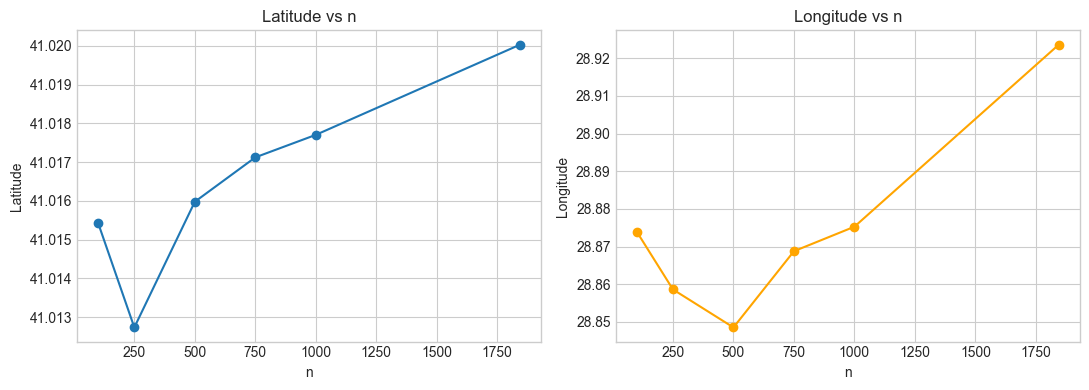

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(n_df['n'], n_df['hub_lat'], marker='o')
ax[0].set_title('Latitude vs n')
ax[0].set_xlabel('n')
ax[0].set_ylabel('Latitude')
ax[0].ticklabel_format(useOffset=False, style='plain', axis='y')

ax[1].plot(n_df['n'], n_df['hub_lon'], marker='o', color='orange')
ax[1].set_title('Longitude vs n')
ax[1].set_xlabel('n')
ax[1].set_ylabel('Longitude')

plt.tight_layout()
plt.savefig(out_dir / 'n_sensitivity.png', dpi=150)
plt.show()

In [28]:
def show_n_solution(n=500):
    lat, lon, cost = solve_for_n(n)
    small_data = model_data.head(n).copy()

    print('n:', n)
    print('Hub latitude:', round(lat, 6))
    print('Hub longitude:', round(lon, 6))
    print('Cost:', round(cost, 2))

    plt.figure(figsize=(7, 5))
    plt.scatter(small_data['lon'], small_data['lat'], c=small_data['risk_weight'], cmap='YlOrRd', s=14, alpha=0.7)
    plt.scatter(lon, lat, marker='*', s=280, color='navy')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Hub Location for Selected n')
    plt.tight_layout()
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        show_n_solution,
        n=widgets.IntSlider(value=500, min=50, max=len(model_data), step=50)
    )
except Exception:
    show_n_solution(500)

interactive(children=(IntSlider(value=500, description='n', max=1845, min=50, step=50), Output()), _dom_classe…

## 16. Short Conclusion

The final result is a first mathematical suggestion for emergency logistics planning.

The model improves the proposal by:

- using Haversine distance,
- giving full dataset links,
- filtering the health dataset according to the project objective,
- adding a realistic discussion about the unconstrained location assumption,
- adding epsilon smoothing for the non-differentiability issue,
- adding an `n` slider for interactivity.